In [1]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


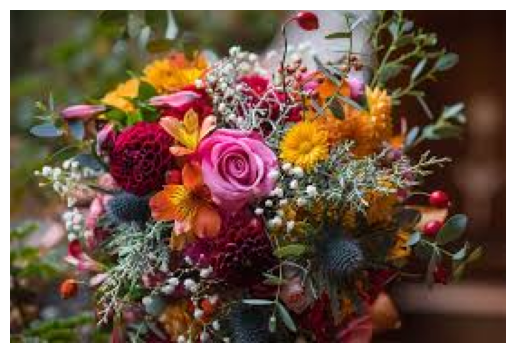

In [3]:
base_path = '/content/drive/MyDrive/CV_Practice/Images/'

flower = mpimg.imread(base_path + 'Flower.jpg')
plt.imshow(flower)
plt.axis('off')
plt.show()

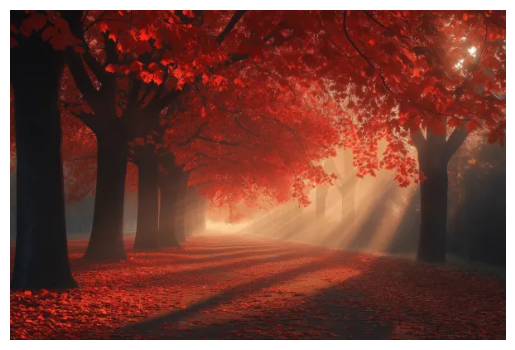

In [4]:
tree = mpimg.imread(base_path + 'Trees.jpg')
plt.imshow(tree)
plt.axis("off")
plt.show()

In [5]:
import torchvision.transforms.v2 as v2

import torch
from torchvision.transforms.functional import to_pil_image
from torchvision.utils import make_grid

### The PyTorch team is basically saying, this in their documentation: **"V2 is legacy. V2 is the future.”** Let’s break this properly.

🔹 V1 (torchvision.transforms)

- Built mainly for image classification

- Primarily designed around PIL Images

- Limited support for tensors

- Detection/segmentation required manual bbox handling

- Not actively evolving

🔹 V2 (torchvision.transforms.v2)

- Designed for modern CV tasks

- Works directly with tensors

- Supports:

    - Images

   - Bounding boxes

  -  Masks

  - Faster

- Future improvements only here

🧠 Why This V2 Matters:

- Moving toward Object Detection

- If going into research / PhD

- Building serious CV foundations

- Detection requires transforming:

   - Image

   -  Bounding boxes

    - Masks

If you flip an image:

V1 → you must manually flip bounding boxes

V2 → bounding boxes are updated automatically

That’s huge.

# Transformations before Augmentation of the Images:

### Converting Numpy arrays to tensor so that we can apply V2 transformations

In [6]:
print('Data types are: ', type(flower), type(tree))
print('Shape of are: ', flower.shape, tree.shape)
print('Size of are: ', flower.size, tree.size)

Data types are:  <class 'numpy.ndarray'> <class 'numpy.ndarray'>
Shape of are:  (184, 274, 3) (399, 599, 3)
Size of are:  151248 717003


In [7]:
transform = v2.ToTensor()

flower = transform(flower)
tree = transform(tree)

print('Data types are: ', type(flower), type(tree))
print('Shape of the images: ', flower.shape, tree.shape)
print('Size of the images: ', flower.size(), tree.size())

Data types are:  <class 'torch.Tensor'> <class 'torch.Tensor'>
Shape of the images:  torch.Size([3, 184, 274]) torch.Size([3, 399, 599])
Size of the images:  torch.Size([3, 184, 274]) torch.Size([3, 399, 599])


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


# 1) Geometric Augmentation

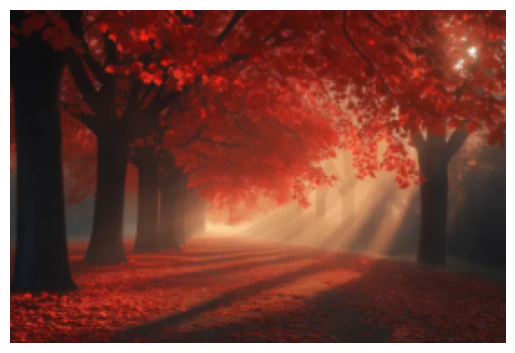

Shape of new_tree (resized image): torch.Size([3, 184, 274])


In [8]:
transform = v2.Resize((184, 274))
new_tree = transform(tree)

plt.imshow(new_tree.permute(1, 2, 0))
plt.axis("off")
plt.show()

print("Shape of new_tree (resized image):", new_tree.shape)

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

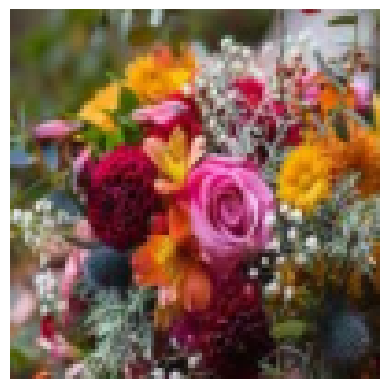

In [9]:
transform = v2.RandomResizedCrop(size = (100, 100), scale = (0.5, 1))
new_fl = transform(flower)

plt.imshow(to_pil_image(new_fl))
plt.axis('off')

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

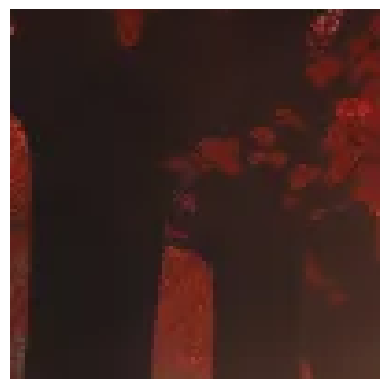

In [10]:
transform = v2.RandomCrop((100, 100), padding = (5, 5), fill = 13)
new_t = transform(tree)

plt.imshow(new_t.permute(1, 2, 0))
plt.axis('off')

(np.float64(-0.5), np.float64(425.5), np.float64(153.5), np.float64(-0.5))

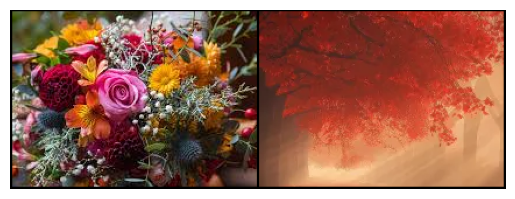

In [11]:
transform = v2.CenterCrop((150, 210))
new_f = transform(flower)
new_t = transform(tree)

# Stack the images into a single batch tensor for make_grid
# make_grid expects input in (N, C, H, W) format, where N is the batch size
stacked_images = torch.stack([new_f, new_t])
grid = make_grid(stacked_images)

plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')

(np.float64(-0.5), np.float64(598.5), np.float64(398.5), np.float64(-0.5))

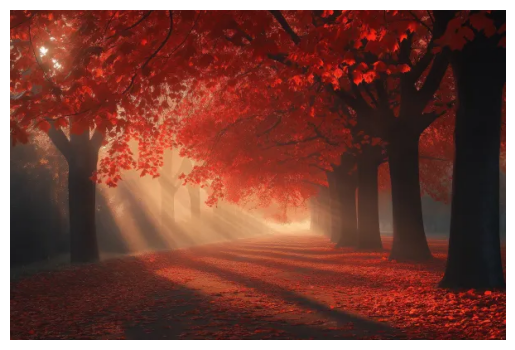

In [12]:
transform = v2.RandomHorizontalFlip(p = 0.9)
new_t = transform(tree)

plt.imshow(to_pil_image(new_t))
plt.axis('off')

(np.float64(-0.5), np.float64(598.5), np.float64(398.5), np.float64(-0.5))

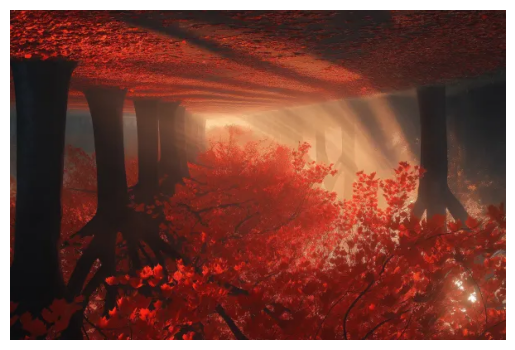

In [13]:
transform = v2.RandomVerticalFlip(p = 1)
new_t = transform(tree)

plt.imshow(to_pil_image(new_t))
plt.axis('off')

(np.float64(-0.5), np.float64(598.5), np.float64(398.5), np.float64(-0.5))

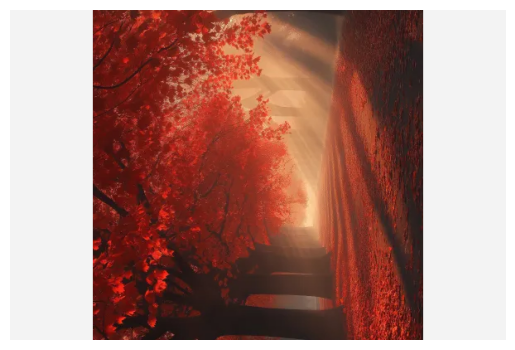

In [14]:
transform = v2.RandomRotation((90, 90), fill = 13)
new_t = transform(tree)

plt.imshow(to_pil_image(new_t))
plt.axis('off')

(np.float64(-0.5), np.float64(598.5), np.float64(398.5), np.float64(-0.5))

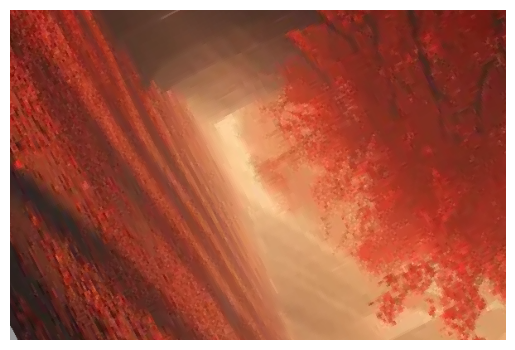

In [15]:
transform = v2.RandomAffine(degrees = (45, 90), translate=(0.5, 0.5), scale = (1.31, 3.31), fill = 871)
new_t = transform(tree)

plt.imshow(to_pil_image(new_t))
plt.axis('off')

(np.float64(-0.5), np.float64(598.5), np.float64(398.5), np.float64(-0.5))

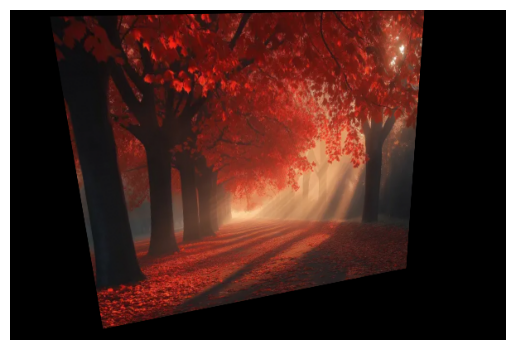

In [16]:
transform = v2.RandomPerspective(distortion_scale=0.5, p=1)
new_t = transform(tree)

plt.imshow(to_pil_image(new_t))
plt.axis('off')

(np.float64(-0.5), np.float64(604.5), np.float64(404.5), np.float64(-0.5))

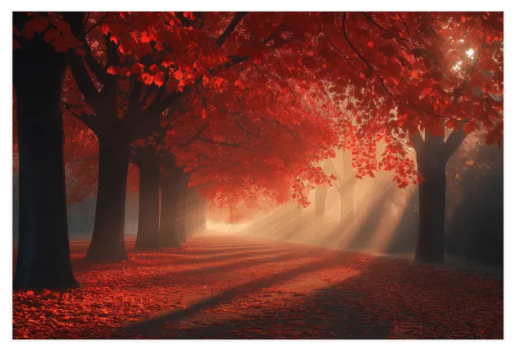

In [17]:
transform = v2.Pad(3, fill = 13, padding_mode = 'constant')
new_t = transform(tree)

plt.imshow(to_pil_image(new_t))
plt.axis('off')

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

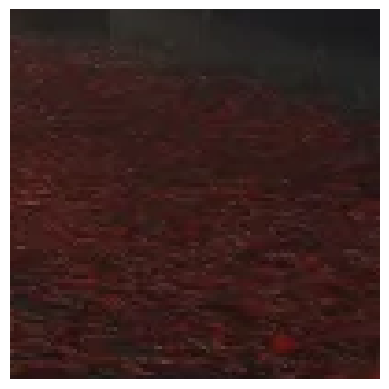

In [18]:
transform = v2.FiveCrop((100, 100))
new_t = transform(tree)

# new_t is a tuple of 5 cropped images, so we need to select one to display.
# For example, to display the first crop:
plt.imshow(to_pil_image(new_t[3]))
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(103.5), np.float64(-0.5))

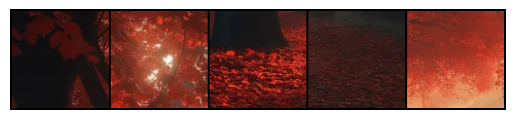

In [19]:
grid = make_grid(list(new_t))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')

(np.float64(-0.5), np.float64(149.5), np.float64(149.5), np.float64(-0.5))

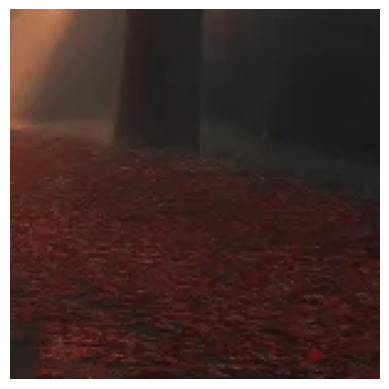

In [20]:
transform = v2.TenCrop((150, 150))
new_t = transform(tree)

plt.imshow(to_pil_image(new_t[3]))
plt.axis('off')

(np.float64(-0.5), np.float64(1217.5), np.float64(305.5), np.float64(-0.5))

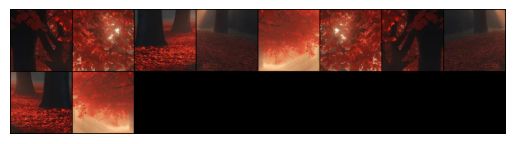

In [21]:
grid = make_grid(list(new_t))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')

# 2) Color/Pixel Augmentation

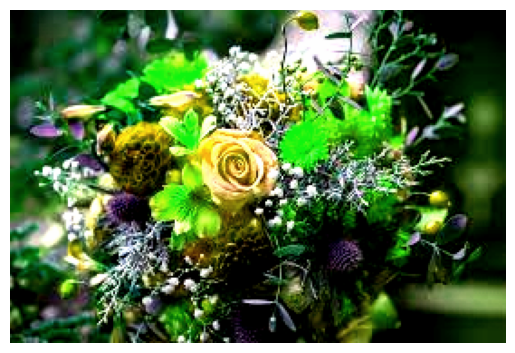

In [22]:
transform = v2.ColorJitter(brightness = (0.7, 1.2), contrast = (0.2, 1.8), saturation = 0.2, hue = 0.3)
new_f = transform(flower)

plt.imshow(to_pil_image(new_f))
plt.axis('off')
plt.show()

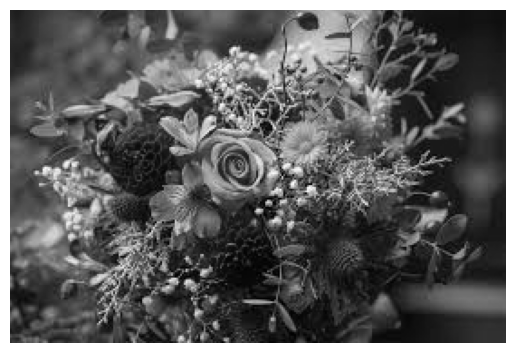

In [23]:
transform = v2.RandomGrayscale(p = 1)
new_f = transform(flower)

plt.imshow(to_pil_image(new_f))
plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(273.5), np.float64(183.5), np.float64(-0.5))

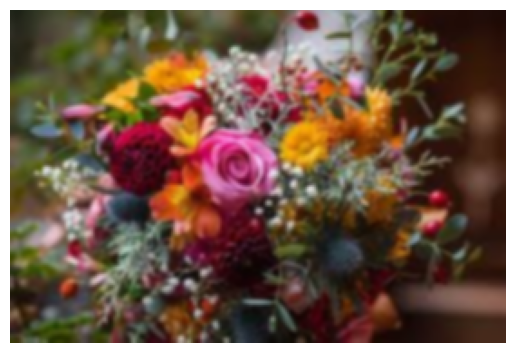

In [24]:
transform = v2.GaussianBlur(kernel_size = (5, 5), sigma = (0.8, 1.2))
new_f = transform(flower)

plt.imshow(to_pil_image(new_f))
plt.axis('off')

(np.float64(-0.5), np.float64(273.5), np.float64(183.5), np.float64(-0.5))

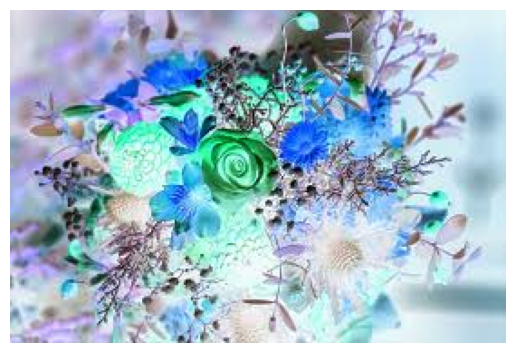

In [25]:
transform = v2.RandomInvert(p = 1)
new_f = transform(flower)

plt.imshow(to_pil_image(new_f))
plt.axis('off')

(np.float64(-0.5), np.float64(273.5), np.float64(183.5), np.float64(-0.5))

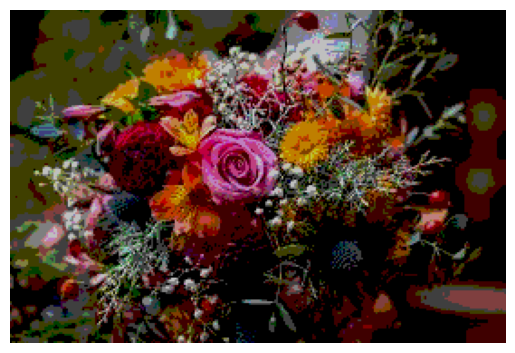

In [26]:
transform = v2.RandomPosterize(bits = 2,  p = 1)
new_f = transform(flower)

plt.imshow(new_f.permute(1, 2, 0))
plt.axis('off')

(np.float64(-0.5), np.float64(273.5), np.float64(183.5), np.float64(-0.5))

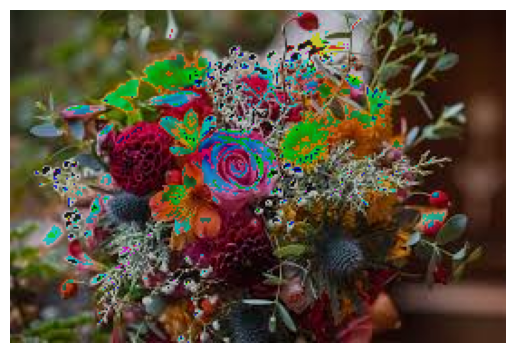

In [27]:
transform = v2.RandomSolarize(threshold = 0.8, p = 1)
new_f = transform(flower)

plt.imshow(to_pil_image(new_f))
plt.axis('off')

(np.float64(-0.5), np.float64(273.5), np.float64(183.5), np.float64(-0.5))

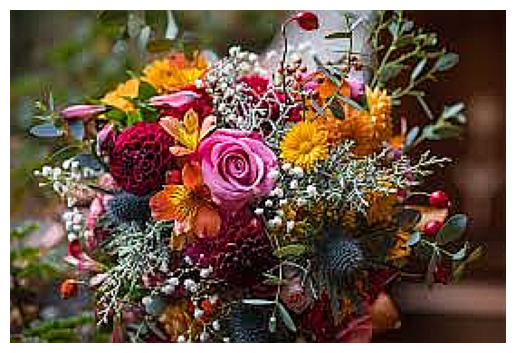

In [28]:
transform = v2.RandomAdjustSharpness(sharpness_factor = 3, p = 1)
new_f = transform(flower)

plt.imshow(to_pil_image(new_f))
plt.axis('off')

(np.float64(-0.5), np.float64(273.5), np.float64(183.5), np.float64(-0.5))

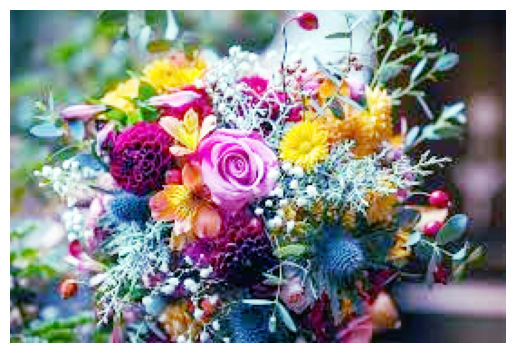

In [29]:
transform = v2.RandomEqualize(p = 1)
new_f = transform(flower)

plt.imshow(to_pil_image(new_f))
plt.axis('off')

# 3) Adavance Augmentation

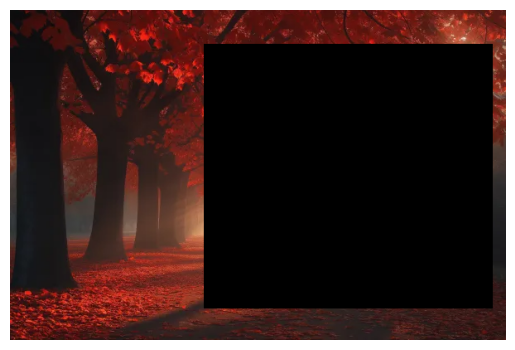

In [30]:
transform = v2.RandomErasing(p = 1, scale = (0.3, 0.5), ratio = (0.5, 2.0))
new_t = transform(tree)

plt.imshow(to_pil_image(new_t))
plt.axis('off')
plt.show()

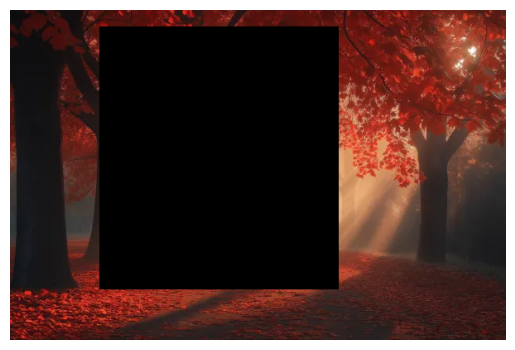

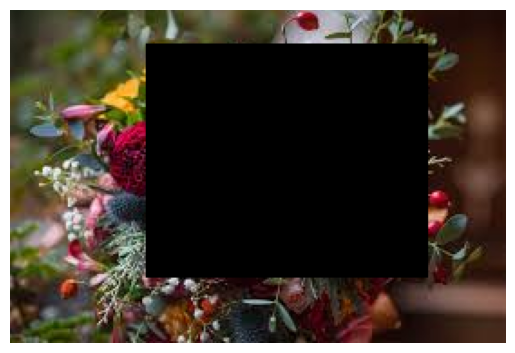

In [31]:
trasnform = v2.RandAugment(num_ops = 8, magnitude = 25)
new_t = transform(tree)
new_f = transform(flower)

plt.imshow(to_pil_image(new_t))
plt.axis('off')
plt.show()

plt.imshow(to_pil_image(new_f))
plt.axis('off')
plt.show()

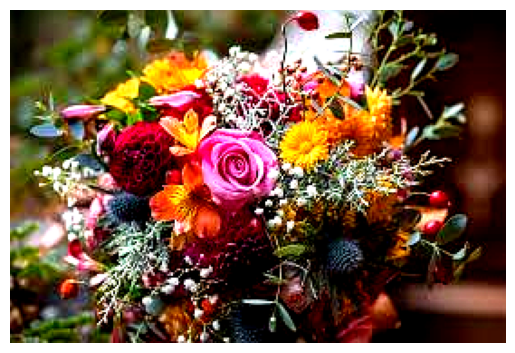

In [32]:
transform = v2.AutoAugment(policy = v2.AutoAugmentPolicy.CIFAR10)
new_f = transform(flower)

plt.imshow(to_pil_image(new_f))
plt.axis('off')
plt.show()

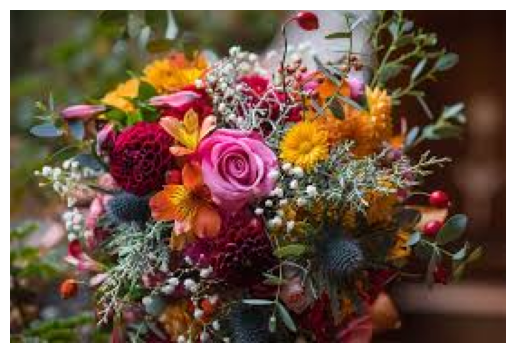

In [33]:
transform = v2.TrivialAugmentWide()
new_f = transform(flower)

plt.imshow(to_pil_image(new_f))
plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(273.5), np.float64(183.5), np.float64(-0.5))

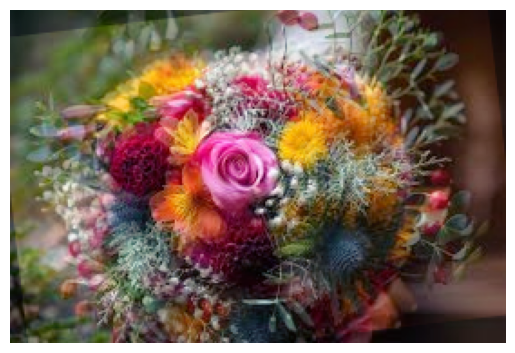

In [35]:
transform = v2.AugMix()
new_f = transform(flower)

plt.imshow(to_pil_image(new_f))
plt.axis('off')